In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Data/Clean/Final-v4.csv")
df

,iso3_i,iso3_j,year,a_ij,M_i,M_j,d_cul,r_i,r_j,Y_i,...,lang_share,lang_official,legal_origin_i,legal_origin_j,fta_wto,euro_i,euro_j,d_ling,eu_i,eu_j
0,ABW,ABW,2017,NaN,5.202674e+08,5.202674e+08,NaN,NaN,NaN,4390.931641,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ABW,ABW,2018,NaN,4.516158e+08,4.516158e+08,NaN,NaN,NaN,4496.186035,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ABW,ABW,2019,NaN,5.161534e+08,5.161534e+08,NaN,NaN,NaN,4395.811523,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ABW,ABW,2020,NaN,4.904604e+08,4.904604e+08,NaN,NaN,NaN,3243.589111,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ABW,ABW,2021,NaN,5.426893e+08,5.426893e+08,NaN,NaN,NaN,4026.352539,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
482155,ZWE,ZWE,2020,NaN,6.355558e+09,6.355558e+09,NaN,NaN,NaN,40970.785156,...,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
482156,ZWE,ZWE,2021,NaN,7.116484e+09,7.116484e+09,NaN,NaN,NaN,44440.199219,...,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
482157,ZWE,ZWE,2022,NaN,6.847418e+09,6.847418e+09,NaN,NaN,NaN,47147.550781,...,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
482158,ZWE,ZWE,2023,NaN,7.354891e+09,7.354891e+09,NaN,NaN,NaN,49685.757812,...,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Fix df_full to only be countries that we have defined it to be
# ── Country set: EU-27 + 4 outside options ────────────────────────────────
EU27 = [
    'AUT','BEL','BGR','HRV','CYP','CZE','DNK','EST','FIN','FRA','DEU','GRC',
    'HUN','IRL','ITA','LVA','LTU','LUX','MLT','NLD','POL','PRT','ROU','SVK',
    'SVN','ESP','SWE'
]
OUTSIDE = ['USA','GBR','CHE','NOR']
COUNTRIES = EU27 + OUTSIDE          # n = 31

df = df[(df["iso3_i"].isin(COUNTRIES)) & (df["iso3_j"].isin(COUNTRIES))]

In [12]:
yr = 2019
yd_df = df[df["year"] == yr]

print("Total rows for 2019:", len(yd_df))
print("Rows where a_ij == 0:", (yd_df["a_ij"] == 0).sum())
print("Rows where a_ij is NaN:", yd_df["a_ij"].isna().sum())
print("Rows where a_ij > 0:", (yd_df["a_ij"] > 0).sum())
print("Rows where a_ij < 0:", (yd_df["a_ij"] < 0).sum())

Total rows for 2019: 961
Rows where a_ij == 0: 0
Rows where a_ij is NaN: 36
Rows where a_ij > 0: 920
Rows where a_ij < 0: 5


In [13]:
yr = 2019
yd_df = df[df["year"] == yr]

neg_rows = yd_df[yd_df["a_ij"] < 0][["iso3_i", "iso3_j", "a_ij"]]
print("Negative a_ij pairs in 2019:")
print(neg_rows.to_string(index=False))

Negative a_ij pairs in 2019:
iso3_i iso3_j         a_ij
   DEU    PRT    -6.740400
   EST    ESP    -0.029289
   FRA    IRL  -675.407178
   GBR    BEL  -515.543735
   GBR    ESP -2412.256560


In [11]:
# Add this cell to identify exactly which 36 pairs are missing
yr = 2019
yd_df = df[df["year"] == yr]

a_ij = yd_df.pivot(index="iso3_i", columns="iso3_j", values="a_ij").reindex(
    index=COUNTRIES, columns=COUNTRIES
)

missing_pairs = (
    a_ij.isna()
    .stack()
    .loc[lambda x: x]
    .reset_index()
    .rename(columns={"iso3_i": "origin", "iso3_j": "destination", 0: "is_missing"})
    .drop(columns="is_missing")
)

print(f"Missing pairs in 2019: {len(missing_pairs)}")
print(missing_pairs.to_string(index=False))

Missing pairs in 2019: 36
origin destination
   AUT         AUT
   BEL         BEL
   BGR         BGR
   HRV         HRV
   HRV         CYP
   HRV         EST
   CYP         HRV
   CYP         CYP
   CZE         CZE
   DNK         DNK
   EST         EST
   FIN         FIN
   FRA         FRA
   DEU         DEU
   GRC         GRC
   GRC         MLT
   HUN         HUN
   IRL         IRL
   ITA         ITA
   LVA         LVA
   LTU         LTU
   LUX         LUX
   MLT         GRC
   MLT         MLT
   NLD         NLD
   POL         POL
   PRT         PRT
   ROU         ROU
   SVK         SVK
   SVN         SVN
   ESP         ESP
   SWE         SWE
   USA         USA
   GBR         GBR
   CHE         CHE
   NOR         NOR


Year 2019: Proportion of zeros in a_ij = 0.00%


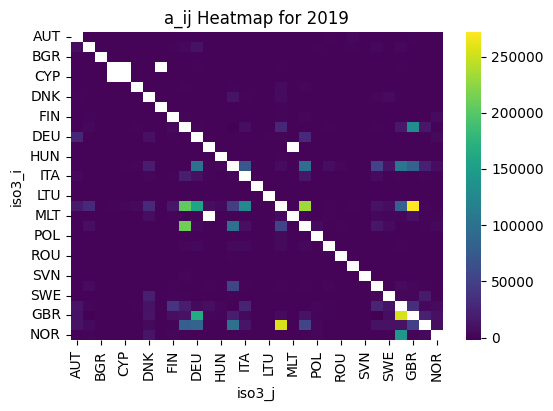

Year 2020: Proportion of zeros in a_ij = 0.00%


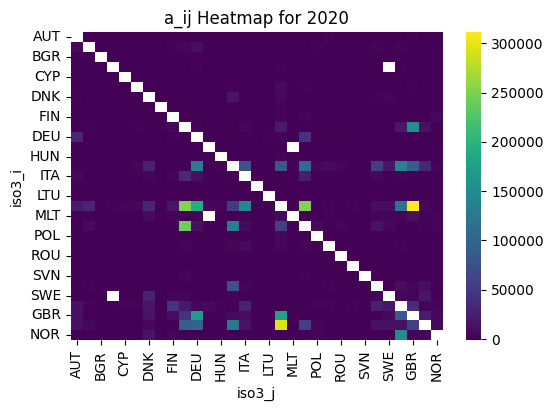

Year 2021: Proportion of zeros in a_ij = 0.00%


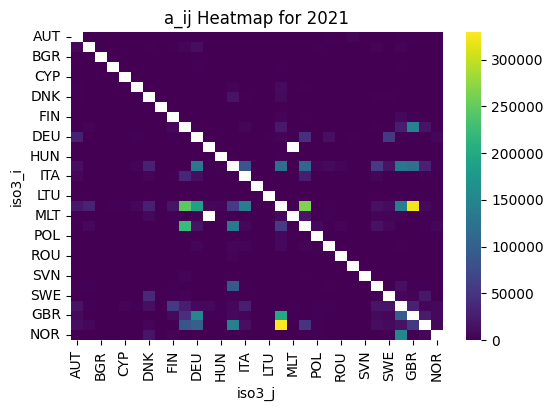

Year 2022: Proportion of zeros in a_ij = 0.00%


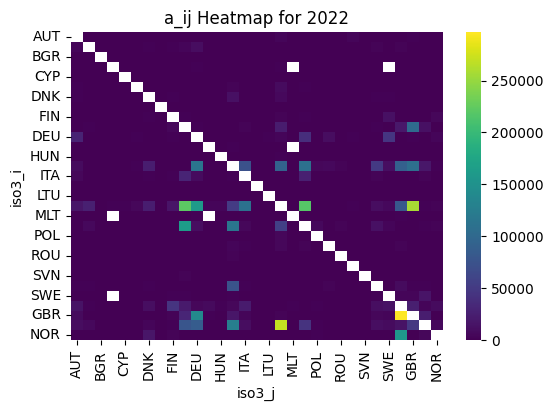

Year 2023: Proportion of zeros in a_ij = 0.00%


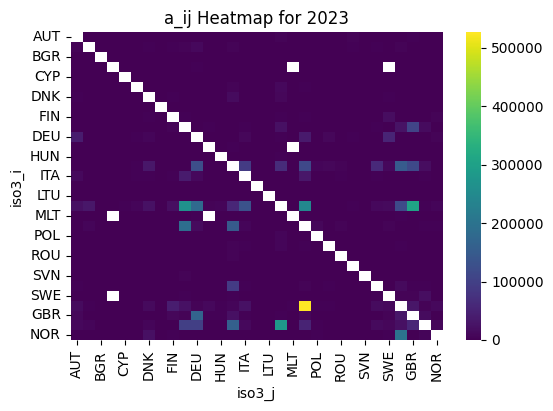

In [9]:
# Plot a heatmap for specific years. This is for inspecting the a_ij matrices.

for yr in range(2019, 2024):
    # Get data
    yd_df = df[df["year"]==yr]
    a_ij = yd_df.pivot(index="iso3_i", columns="iso3_j", values="a_ij").reindex(index=COUNTRIES, columns=COUNTRIES)
    # Get proportion of zeros
    zero_prop = (a_ij == 0).mean().mean()
    print(f"Year {yr}: Proportion of zeros in a_ij = {zero_prop:.2%}")
    # # Set 0 to nan
    # a_ij = a_ij.replace(0, np.nan)
    # # Log it
    # a_ij = np.log(a_ij)
    # a_ij = a_ij.clip(lower=0)
    
    plt.figure(figsize=(6,4))
    sns.heatmap(a_ij, cmap="viridis")
    plt.title(f"a_ij Heatmap for {yr}")
    plt.show()